Гипотеза 7: стратифицированная кросс-валидация

Посмотрим на рахницу между двумя подходами: обучение на 100% тренировочных данных, и стратифицированная 5-ти фолдовая кросс-валидация

In [9]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

In [2]:
df_train = pd.read_csv('train_final_processed.csv')
df_test = pd.read_csv('test_final_processed.csv')
print(f"Размер тренировочных данных: {df_train.shape}")
print(f"Размер тестовых данных: {df_test.shape}")

Размер тренировочных данных: (307511, 571)
Размер тестовых данных: (48744, 570)


In [3]:
X_train_full = df_train.drop(['sk_id_curr', 'target'], axis=1)
y_train_full = df_train['target']

In [4]:
if y_train_full.dtype == 'object' or len(y_train_full.unique()) > 2:
    y_train_full = y_train_full.map({'0': 0, '1': 1}).fillna(0).astype(int)

In [5]:
common_cols = X_train_full.columns.intersection(df_test.drop(['sk_id_curr'], axis=1).columns)
if len(common_cols) < 10:
    print("Предупреждение")
X_train_full = X_train_full[common_cols]
df_test_processed = df_test[common_cols]

In [6]:
cat_cols = [col for col in common_cols if X_train_full[col].dtype == 'object']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train_full[col] = X_train_full[col].astype(str).fillna('missing')
    df_test_processed[col] = df_test_processed[col].astype(str).fillna('missing')
    
    all_values = pd.concat([X_train_full[col], df_test_processed[col]], axis=0).unique()
    le.fit(all_values) 
    
    X_train_full[col] = le.transform(X_train_full[col])
    df_test_processed[col] = le.transform(df_test_processed[col])

C:\Users\klmv0\AppData\Local\Temp\ipykernel_31376\1254183696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = df_test_processed[col].astype(str).fillna('missing')
C:\Users\klmv0\AppData\Local\Temp\ipykernel_31376\1254183696.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = le.transform(df_test_processed[col])
C:\Users\klmv0\AppData\Local\Temp\ipykernel_31376\1254183696.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

In [7]:
for col in X_train_full.columns:
    X_train_full[col] = pd.to_numeric(X_train_full[col], errors='coerce')
    df_test_processed[col] = pd.to_numeric(df_test_processed[col], errors='coerce')

for col in X_train_full.columns:
    if X_train_full[col].dtype in ['float64', 'int64']:
        X_train_full[col].fillna(X_train_full[col].median(), inplace=True)
        df_test_processed[col].fillna(X_train_full[col].median(), inplace=True)

C:\Users\klmv0\AppData\Local\Temp\ipykernel_31376\1661528756.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col] = pd.to_numeric(df_test_processed[col], errors='coerce')
C:\Users\klmv0\AppData\Local\Temp\ipykernel_31376\1661528756.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_processed[col].fillna(X_train_full[col].median(), inplace=True)
C:\Users\klmv0\AppData\Local\Temp\ipykernel_31376\1661528756.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documenta

In [8]:
catboost_params = {
    'iterations': 1000,     
    'learning_rate': 0.03,       
    'depth': 7,          
    'auto_class_weights': 'SqrtBalanced',
    'random_state': 42,
    'l2_leaf_reg': 2,  
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'verbose': 100
}

In [10]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X_train_full))
test_predictions = np.zeros(len(df_test_processed))
fold_scores = []

print(f"Количество фолдов: {n_splits}")
print(f"Размерность данных: {X_train_full.shape}")

Количество фолдов: 5
Размерность данных: (307511, 569)


In [11]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
    print(f"\n--- Фолд {fold + 1} ---")
    
    X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    
    print(f"Тренировочные данные: {X_train.shape}")
    print(f"Валидационные данные: {X_val.shape}")
    print(f"Распределение целевой переменной в трейне: {np.bincount(y_train)}")
    print(f"Распределение целевой переменной в валидации: {np.bincount(y_val)}")
    
    model = CatBoostClassifier(**catboost_params)
    
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        verbose=100
    )
    
    val_pred = model.predict_proba(X_val)[:, 1]
    oof_predictions[val_idx] = val_pred
    
    test_pred = model.predict_proba(df_test_processed)[:, 1]
    test_predictions += test_pred / n_splits
    
    fold_auc = roc_auc_score(y_val, val_pred)
    fold_scores.append(fold_auc)
    print(f"AUC на фолде {fold + 1}: {fold_auc:.4f}")


--- Фолд 1 ---
Тренировочные данные: (246008, 569)
Валидационные данные: (61503, 569)
Распределение целевой переменной в трейне: [226148  19860]
Распределение целевой переменной в валидации: [56538  4965]
0:	test: 0.6850453	best: 0.6850453 (0)	total: 594ms	remaining: 9m 53s
100:	test: 0.7581300	best: 0.7581300 (100)	total: 36.6s	remaining: 5m 26s
200:	test: 0.7677337	best: 0.7677337 (200)	total: 1m 14s	remaining: 4m 57s
300:	test: 0.7718681	best: 0.7718681 (300)	total: 1m 56s	remaining: 4m 30s
400:	test: 0.7746248	best: 0.7746248 (400)	total: 2m 31s	remaining: 3m 46s
500:	test: 0.7775875	best: 0.7775875 (500)	total: 3m 5s	remaining: 3m 4s
600:	test: 0.7794392	best: 0.7794422 (599)	total: 3m 38s	remaining: 2m 25s
700:	test: 0.7806628	best: 0.7807158 (697)	total: 4m 13s	remaining: 1m 48s
800:	test: 0.7814687	best: 0.7814687 (800)	total: 4m 47s	remaining: 1m 11s
900:	test: 0.7820944	best: 0.7820944 (900)	total: 5m 18s	remaining: 35s
999:	test: 0.7824101	best: 0.7824253 (964)	total: 5m 49

In [50]:
cat_model_optimal = CatBoostClassifier(
    iterations=1000,     
    learning_rate=0.03,       
    depth=7,          
    auto_class_weights='SqrtBalanced',
    random_state=42,
    l2_leaf_reg=2,  
    eval_metric='AUC',
    loss_function='Logloss',
    verbose=100)

cat_model_optimal.fit(X_train, y_train, eval_set=(X_val, y_val), cat_features=cat_cols)

0:	test: 0.6920145	best: 0.6920145 (0)	total: 1.27s	remaining: 21m 11s
100:	test: 0.7635603	best: 0.7635603 (100)	total: 40.4s	remaining: 5m 59s
200:	test: 0.7736460	best: 0.7736460 (200)	total: 1m 19s	remaining: 5m 14s
300:	test: 0.7779570	best: 0.7779570 (300)	total: 1m 56s	remaining: 4m 29s
400:	test: 0.7803523	best: 0.7803523 (400)	total: 2m 32s	remaining: 3m 47s
500:	test: 0.7831461	best: 0.7831461 (500)	total: 3m 8s	remaining: 3m 7s
600:	test: 0.7847061	best: 0.7847061 (600)	total: 3m 56s	remaining: 2m 36s
700:	test: 0.7856218	best: 0.7856218 (700)	total: 4m 38s	remaining: 1m 58s
800:	test: 0.7863940	best: 0.7863940 (800)	total: 5m 18s	remaining: 1m 19s
900:	test: 0.7868396	best: 0.7868396 (900)	total: 5m 52s	remaining: 38.8s
999:	test: 0.7871743	best: 0.7871743 (999)	total: 6m 29s	remaining: 0us

bestTest = 0.7871743116
bestIteration = 999



In [12]:
print(f"Средний AUC: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
print(f"Оценки по фолдам: {[f'{score:.4f}' for score in fold_scores]}")

oof_pred_binary = (oof_predictions > 0.5).astype(int)


print(f"OOF ROC-AUC: {roc_auc_score(y_train_full, oof_predictions):.4f}")
print(f"Accuracy: {accuracy_score(y_train_full, oof_pred_binary):.4f}")
print(f"Precision: {precision_score(y_train_full, oof_pred_binary):.4f}")
print(f"Recall: {recall_score(y_train_full, oof_pred_binary):.4f}")
print(f"F1-Score: {f1_score(y_train_full, oof_pred_binary):.4f}")

Средний AUC: 0.7846 (+/- 0.0044)
Оценки по фолдам: ['0.7824', '0.7910', '0.7804', '0.7887', '0.7805']
OOF ROC-AUC: 0.7846
Accuracy: 0.9029
Precision: 0.3581
Recall: 0.2565
F1-Score: 0.2989


In [13]:
final_model = CatBoostClassifier(**catboost_params)
final_model.fit(X_train_full, y_train_full, verbose=100)

final_test_predictions = final_model.predict_proba(df_test_processed)[:, 1]

0:	total: 932ms	remaining: 15m 31s
100:	total: 53.9s	remaining: 7m 59s
200:	total: 1m 48s	remaining: 7m 10s
300:	total: 2m 59s	remaining: 6m 57s
400:	total: 4m 2s	remaining: 6m 2s
500:	total: 4m 53s	remaining: 4m 51s
600:	total: 5m 44s	remaining: 3m 48s
700:	total: 6m 28s	remaining: 2m 45s
800:	total: 7m 12s	remaining: 1m 47s
900:	total: 7m 57s	remaining: 52.5s
999:	total: 8m 41s	remaining: 0us


In [14]:
print(f"\nСравнение предсказаний:")
print(f"CV предсказания - среднее: {test_predictions.mean():.4f}, std: {test_predictions.std():.4f}")
print(f"Финальная модель - среднее: {final_test_predictions.mean():.4f}, std: {final_test_predictions.std():.4f}")


Сравнение предсказаний:
CV предсказания - среднее: 0.1831, std: 0.1419
Финальная модель - среднее: 0.1842, std: 0.1437


In [16]:
test_pred_proba_final = final_model.predict_proba(df_test_processed)[:, 1]

submission_final = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_pred_proba_final
})
submission_final.to_csv('submission_hypothesis_7.csv', index=False)

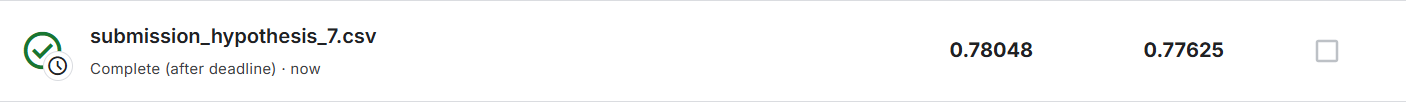

Стратифицированная кросс-валидация

In [18]:
submission_cv = pd.DataFrame({
    'sk_id_curr': df_test['sk_id_curr'],
    'target': test_predictions
})
submission_cv.to_csv('submission_hypothesis_7_1.csv', index=False)


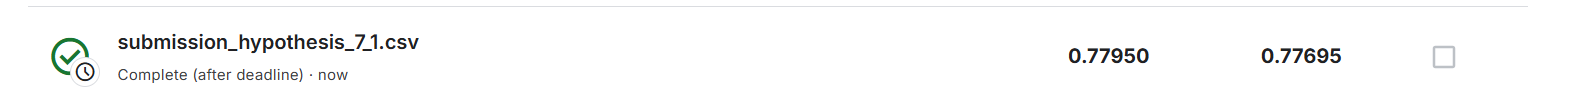